# Subsetting: the non-immune compartment

From `shiao.h5ad` (619,693 x 30,869, phase 01) to a raw, re-filtered object holding only the
cells whose CellTypist lineage is non-immune (`fraction == 'non_imm'`).

- subset `fraction == 'non_imm'`, the biological immune/non-immune class recoded in 01_4
- restore `.X` = raw counts and drop every slot that phase 01 computed on the full object
  (PCA, UMAP, neighbours, HVG flags, scran size factors, leiden columns)
- drop the categories left empty by the subset (`cell_type` goes from 48 to 18 observed labels)
- recompute the QC metrics, re-apply the cell thresholds and re-run the gene filter
- drop the cohorts that no longer cover all three timepoints (0 cells in BASE, PD1 or RTPD1)
- write `shiao_nonimm_raw.h5ad`, the input of `subsetting_all.sh`

Nothing is normalized here: scran runs in the next step, on this file, because its size
factors have to be estimated on the cells that remain.

## Packages and paths

In [44]:
# Core scverse libraries
from __future__ import annotations

# Main
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import os

# Plotting
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sns

# Scanpy setting: clean white background and high resolution figures
sc.set_figure_params(dpi=300, facecolor="white")
# Set the level of verbosity of scanpy to get more detailed info
sc.settings.verbosity = 3

PHASE_DIR = os.path.dirname(os.getcwd())  # 03_drvi_non_immune/
REPO_ROOT = os.path.dirname(PHASE_DIR)

FIG_DIR = os.environ.get("FIG_DIR", os.path.join(PHASE_DIR, "figures", "03_1_subset_and_qc"))
os.makedirs(FIG_DIR, exist_ok=True)
sc.settings.figdir = FIG_DIR

print("cwd      :", os.getcwd())
print("REPO_ROOT:", REPO_ROOT)
print("FIG_DIR  :", FIG_DIR)

# Tell Juptyter to show all outputs and not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

cwd      : /home/albertoc/Desktop/QCB-Master-Thesis/03_drvi_interpretation/03_1_subsetting
REPO_ROOT: /home/albertoc/Desktop/QCB-Master-Thesis
FIG_DIR  : /home/albertoc/Desktop/QCB-Master-Thesis/03_drvi_interpretation/figures/03_1_subset_and_qc


Setup the directory of the data. This is the path to the cluster data folder (outside the repo) or to
the local data folder, like in this case.
Raw and heavy intermediate objects live here; the repo holds only code and lightweight QC figures.

Everything this phase produces goes in its own `03_nonimm/` subfolder, so the non-immune chain never
gets confused with the whole-dataset one.

In [45]:
DATA_DIR = os.environ.get("DATA_DIR", "").strip() or "datasets"
DATA_DIR = os.path.abspath(os.path.join(REPO_ROOT, os.path.expanduser(DATA_DIR)))
os.environ["DATA_DIR"] = DATA_DIR  # absolute from now on: re-running this cell is a no-op

# Input: the definitive unintegrated object from 01_5
INPUT_H5AD = os.path.join(DATA_DIR, "shiao.h5ad")
if not os.path.exists(INPUT_H5AD):
    raise FileNotFoundError(
        f"input not found: {INPUT_H5AD}\n"
        f"(repo root {REPO_ROOT}: run this notebook from 03_1_subsetting/, or set DATA_DIR)"
    )
NONIMM_DIR = os.path.join(DATA_DIR, "03_nonimm")
OUTPUT_H5AD = os.path.join(NONIMM_DIR, "shiao_nonimm_raw.h5ad")
os.makedirs(NONIMM_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("Input   :", INPUT_H5AD, f"({os.path.getsize(INPUT_H5AD) / 1024 ** 3:.2f} GB)")
print("Output  :", OUTPUT_H5AD)

DATA_DIR: /home/albertoc/Desktop/QCB-Master-Thesis/datasets
Input   : /home/albertoc/Desktop/QCB-Master-Thesis/datasets/shiao.h5ad (4.41 GB)
Output  : /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/shiao_nonimm_raw.h5ad


## Parameters

The cell thresholds are the same as 01_2.
This is the place to make the non-immune compartment stricter.

`MIN_CELLS = 3` is the one real change from 01_2, which used `min_cells=1`: on 176k cells a gene
seen in one or two of them carries no usable signal and only inflates the denominator of the HVG
ranking and of the metrics.

Scrublet is deliberately not re-run: doublet detection was done per biopsy on the full object, where
the mixture of lineages is what makes a doublet detectable in the first place. Re-running it inside a
single lineage would be worse, not better.

In [46]:
FRACTION_KEY = "fraction"
FRACTION_KEEP = "non_imm"
BATCH_KEY = "cohort"
LABEL_KEY = "cell_type"
TREATMENT_KEY = "treatment"

MIN_CELLS = 3                   # gene filter: keep genes detected in >= MIN_CELLS cells
MIN_GENES = 100                 # cell filter: keep cells with n_genes_by_counts > MIN_GENES
MAX_PCT_MT = 10                 # cell filter: keep cells with pct_counts_mt < MAX_PCT_MT

MIN_CELLS_PER_COHORT = 200      # reporting threshold for the batch census below
DROP_SMALL_COHORTS = False      # set True to actually drop the cohorts under it

REQUIRED_TREATMENTS = ("BASE", "PD1", "RTPD1")
DROP_INCOMPLETE_COHORTS = True  # drop cohorts with 0 cells in any of REQUIRED_TREATMENTS

## Load the full object

In [47]:
adata = ad.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 619693 × 30869
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'size_factors', 'S_score', 'G2M_score', 'phase', 'cell_type', 'celltypist_predicted', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts',

In [48]:
# What is inside the object
print("obs :", list(adata.obs.columns))
print("var :", list(adata.var.columns))
print("obsm:", list(adata.obsm), "| varm:", list(adata.varm), "| obsp:", list(adata.obsp))
print("uns :", list(adata.uns))
print("layers:", list(adata.layers))

obs : ['sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'size_factors', 'S_score', 'G2M_score', 'phase', 'cell_type', 'celltypist_predicted', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden']
var : ['gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_c

## Subset: the non-immune compartment

In [49]:
# `fraction` is the biological lineage recoded in 01_4/fraction_reassignment.py from the
# CellTypist annotation (imm / non_imm), not the technical CD45 sort.
adata.obs[FRACTION_KEY].value_counts()

fraction
imm        443083
non_imm    176610
Name: count, dtype: int64

In [50]:
n_before = adata.n_obs
nonimm = adata[adata.obs[FRACTION_KEY] == FRACTION_KEEP].copy()
print(f"Cells: {n_before:,} -> {nonimm.n_obs:,} "
      f"({100 * nonimm.n_obs / n_before:.1f}% of the full object)")
nonimm

Cells: 619,693 -> 176,610 (28.5% of the full object)


AnnData object with n_obs × n_vars = 176610 × 30869
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'size_factors', 'S_score', 'G2M_score', 'phase', 'cell_type', 'celltypist_predicted', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts',

In [51]:
del adata

In [52]:
# The composition this phase will work with, before any further filtering.
print("Cells per cell_type:")
print(nonimm.obs[LABEL_KEY].value_counts().loc[lambda s: s > 0])
print("\nCells per cohort x treatment:")
pd.crosstab(nonimm.obs[BATCH_KEY], nonimm.obs["treatment"])

Cells per cell_type:
cell_type
Fibro-matrix       48181
Lumsec-prol        24647
LummHR-major       18401
Lumsec-basal       17729
Vas-venous         15869
Fibro-prematrix     9844
Vas-capillary       9571
vsmc                6789
pericytes           6355
LummHR-SCGB         6000
Vas-arterial        3531
basal               3317
Lumsec-major        1417
Lumsec-myo          1412
Lumsec-KIT          1344
LummHR-active       1088
Lymph-major         1018
Lumsec-HLA            97
Name: count, dtype: int64

Cells per cohort x treatment:


treatment,BASE,PD1,RTPD1
cohort,,,
Patient01,1398,0,411
Patient02,143,248,310
Patient03,207,269,133
Patient04,433,32,114
Patient05,223,821,323
Patient06,1378,138,655
Patient07,258,111,309
Patient09,406,266,245
Patient10,1235,946,431


## Restore the raw counts and drop the phase-01 global slots

`.X` in `shiao.h5ad` is the scran log-normalized matrix of the full object: its size factors were
deconvolved from pools of 619,693 cells and do not describe this subset. `.layers['counts']` is the
only matrix that survives a subset unchanged, so it becomes `.X` again and
`scran_norm_nonimm.py` re-normalizes from there.

The same argument applies to everything else phase 01 derived: the PCA was computed on HVGs selected
across a mostly-immune population, the neighbour graph and the UMAP on that PCA, the leiden columns
on that graph. Keeping any of it would be worse than useless - `use_rep='X_pca'` downstream would
silently point at the old embedding.

In [53]:
# Raw counts back in .X (kept in .layers['counts'] as well, untouched)
counts = nonimm.layers["counts"]
nonimm.X = counts.copy()
if sp.issparse(nonimm.X) and not sp.isspmatrix_csr(nonimm.X):
    nonimm.X = nonimm.X.tocsr()

x_values = nonimm.X.data if sp.issparse(nonimm.X) else np.asarray(nonimm.X).ravel()
print("dtype:", nonimm.X.dtype, "| integer values:", bool(np.allclose(x_values, np.round(x_values))))
print("min:", x_values.min(), "| max:", x_values.max())

dtype: float32 | integer values: True
min: 1.0 | max: 11105.0


In [54]:
# Drop the derived matrices and graphs
for key in list(nonimm.obsm):
    print("removing obsm:", key); del nonimm.obsm[key]
for key in list(nonimm.varm):
    print("removing varm:", key); del nonimm.varm[key]
for key in list(nonimm.obsp):
    print("removing obsp:", key); del nonimm.obsp[key]

# Drop the derived .uns entries: the graph/embedding parameters, the leiden run parameters
# of 01_5, and the *_colors palettes.
UNS_DROP = ("neighbors", "umap", "pca", "hvg", "log1p")
for key in list(nonimm.uns):
    if key in UNS_DROP or key.endswith("_colors") or key.startswith("optscib_"):
        print("removing uns:", key); del nonimm.uns[key]
print("\nkept uns:", list(nonimm.uns))

removing obsm: X_pca
removing obsm: X_umap
removing varm: PCs
removing obsp: connectivities
removing obsp: distances
removing uns: cell_type_colors
removing uns: dataset_origin_colors
removing uns: log1p
removing uns: neighbors
removing uns: optscib_unintegrated_leiden_0.1
removing uns: optscib_unintegrated_leiden_0.2
removing uns: optscib_unintegrated_leiden_0.3
removing uns: optscib_unintegrated_leiden_0.4
removing uns: optscib_unintegrated_leiden_0.5
removing uns: optscib_unintegrated_leiden_0.6
removing uns: optscib_unintegrated_leiden_0.7
removing uns: optscib_unintegrated_leiden_0.8
removing uns: optscib_unintegrated_leiden_0.9
removing uns: optscib_unintegrated_leiden_1.0
removing uns: pca
removing uns: umap

kept uns: []


In [55]:
# Drop the derived .obs columns: scran size factors, the leiden sweep of 01_5, and the cell
# cycle scores.
obs_drop = [c for c in nonimm.obs.columns
            if c == "size_factors"
            or c.startswith("optscib_unintegrated_leiden")
            or c in ("S_score", "G2M_score", "phase")]
print("dropping obs:", obs_drop)
nonimm.obs = nonimm.obs.drop(columns=obs_drop)

# Drop the derived .var columns: the batch-aware HVG selection of 01_5 and the per-gene QC
# statistics of 01_2, all computed on the full object. QC is recomputed below; the HVGs are
# reselected in reduce_data_nonimm.py. Everything else ('gene_ids', 'feature_types',
# 'genome': the annotation that came with the counts) stays.
VAR_DROP = {
    # per-gene QC from 01_2
    "n_cells", "n_cells_by_counts", "mean_counts", "log1p_mean_counts",
    "pct_dropout_by_counts", "total_counts", "log1p_total_counts",
    "mt", "ribo",
    # batch-aware HVG selection from 01_5
    "highly_variable", "highly_variable_nbatches", "highly_variable_intersection",
    "means", "dispersions", "dispersions_norm",
}
var_drop = [c for c in nonimm.var.columns if c in VAR_DROP]
print("dropping var:", var_drop)
print("keeping var :", [c for c in nonimm.var.columns if c not in VAR_DROP])
nonimm.var = nonimm.var.drop(columns=var_drop)
nonimm

dropping obs: ['size_factors', 'S_score', 'G2M_score', 'phase', 'optscib_unintegrated_leiden_0.1', 'optscib_unintegrated_leiden_0.2', 'optscib_unintegrated_leiden_0.3', 'optscib_unintegrated_leiden_0.4', 'optscib_unintegrated_leiden_0.5', 'optscib_unintegrated_leiden_0.6', 'optscib_unintegrated_leiden_0.7', 'optscib_unintegrated_leiden_0.8', 'optscib_unintegrated_leiden_0.9', 'optscib_unintegrated_leiden_1.0', 'optscib_unintegrated_leiden']
dropping var: ['mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable']
keeping var : ['gene_ids', 'feature_types', 'genome']


AnnData object with n_obs × n_vars = 176610 × 30869
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'cell_type', 'celltypist_predicted'
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'counts', None (.X)

### Categories left empty by the subset

`cell_type` is a categorical with the 48 labels observed in the full object; after the subset only the
non-immune ones carry cells. Empty categories are not cosmetic: they end up in the NMI computation of
the leiden sweep, in every `groupby`, and in the legends of every figure.

In [56]:
for col in nonimm.obs.columns:
    if isinstance(nonimm.obs[col].dtype, pd.CategoricalDtype):
        before = len(nonimm.obs[col].cat.categories)
        nonimm.obs[col] = nonimm.obs[col].cat.remove_unused_categories()
        after = len(nonimm.obs[col].cat.categories)
        if before != after:
            print(f"{col}: {before} -> {after} categories")

print("\nObserved labels:", nonimm.obs[LABEL_KEY].nunique())
print("Observed batches:", nonimm.obs[BATCH_KEY].nunique())
print("fraction:", nonimm.obs[FRACTION_KEY].cat.categories.tolist(),
      "(constant by construction: it is no longer usable as a covariate)")


Observed labels: 18
Observed batches: 34
fraction: ['non_imm'] (constant by construction: it is no longer usable as a covariate)


## Quality control metrics, recomputed

The QC columns inherited from 01_2 describe the full gene set of the full object. `total_counts` and
`n_genes_by_counts` are per-cell sums, so they are unchanged by removing *cells*, but they will change
as soon as genes are dropped below - and the mitochondrial and ribosomal flags have to be rebuilt on
the current `.var` anyway.

In [57]:
nonimm.var["mt"] = np.asarray(nonimm.var_names.str.startswith("MT-"), dtype=bool)
nonimm.var["ribo"] = np.asarray(nonimm.var_names.str.startswith(("RPS", "RPL")), dtype=bool)

sc.pp.calculate_qc_metrics(
    nonimm,
    qc_vars=["mt", "ribo"],
    inplace=True,
    percent_top=None,
    log1p=True,
)
print("MT genes flagged  :", int(nonimm.var["mt"].sum()))
print("Ribo genes flagged:", int(nonimm.var["ribo"].sum()))
nonimm.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo"]].describe()

MT genes flagged  : 13
Ribo genes flagged: 102


,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo
count,176610.000000,176610.00000,176610.000000,176610.000000
mean,5251.199219,1634.52813,3.719370,19.254166
std,6578.550293,1224.45876,2.298230,8.483095
min,119.000000,101.00000,0.000000,0.092166
25%,1226.000000,676.00000,2.066498,13.389358
50%,2881.000000,1289.00000,3.357004,18.187018
75%,6556.000000,2228.00000,5.108661,23.750000
max,84662.000000,9355.00000,9.998501,77.197800


### QC figures (before the cell filter)

Two figures per round: a clean one, readable, and a jittered one that shows where the
cells actually sit. Same panels as 01_2, plus `pct_counts_ribo`.


In [ ]:
# Violin plots in the style of 01_2: seaborn, one panel per metric, and two versions of every
# round - a clean one and a jittered one. The helper is defined here and called again after each
# filtering step, so the rounds are strictly comparable.
#
# The jittered version draws a random SUBSAMPLE of the cells, not all of them. At 176k points per
# panel the strip is a solid black band that hides the violin it is supposed to annotate, which
# is exactly what the first version of these figures looked like. The subsample is drawn once
# with a fixed seed, so every panel of every round shows the same cells.
QC_METRICS = ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]
STRIP_MAX_POINTS = 20000

def violin_qc(obs, stage, suffix="nonimm", metrics=QC_METRICS, max_points=STRIP_MAX_POINTS):
    """Write violin_<suffix>_qc_<stage>_unintegrated[_jitter].png to FIG_DIR."""
    rng = np.random.default_rng(0)
    if len(obs) > max_points:
        strip_obs = obs.iloc[np.sort(rng.choice(len(obs), size=max_points, replace=False))]
    else:
        strip_obs = obs

    for jitter in (False, True):
        fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 4))
        for ax, metric in zip(np.atleast_1d(axes), metrics):
            sns.violinplot(data=obs, y=metric, ax=ax, color="tab:blue", cut=0)
            if jitter:
                sns.stripplot(data=strip_obs, y=metric, ax=ax, color="black",
                              size=1, alpha=0.2, jitter=0.25)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_title(metric)

        head = f"QC metrics, {stage.replace('_', ' ')} - {len(obs):,} cells"
        fig.suptitle(head + (f", jitter on {len(strip_obs):,} of them" if jitter else ""))
        fig.tight_layout()
        name = f"violin_{suffix}_qc_{stage}_unintegrated{'_jitter' if jitter else ''}.png"
        fig.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches="tight")
        print("wrote", name)
        plt.show()

violin_qc(nonimm.obs, "before_filter")

/tmp/ipykernel_208095/2187793494.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(


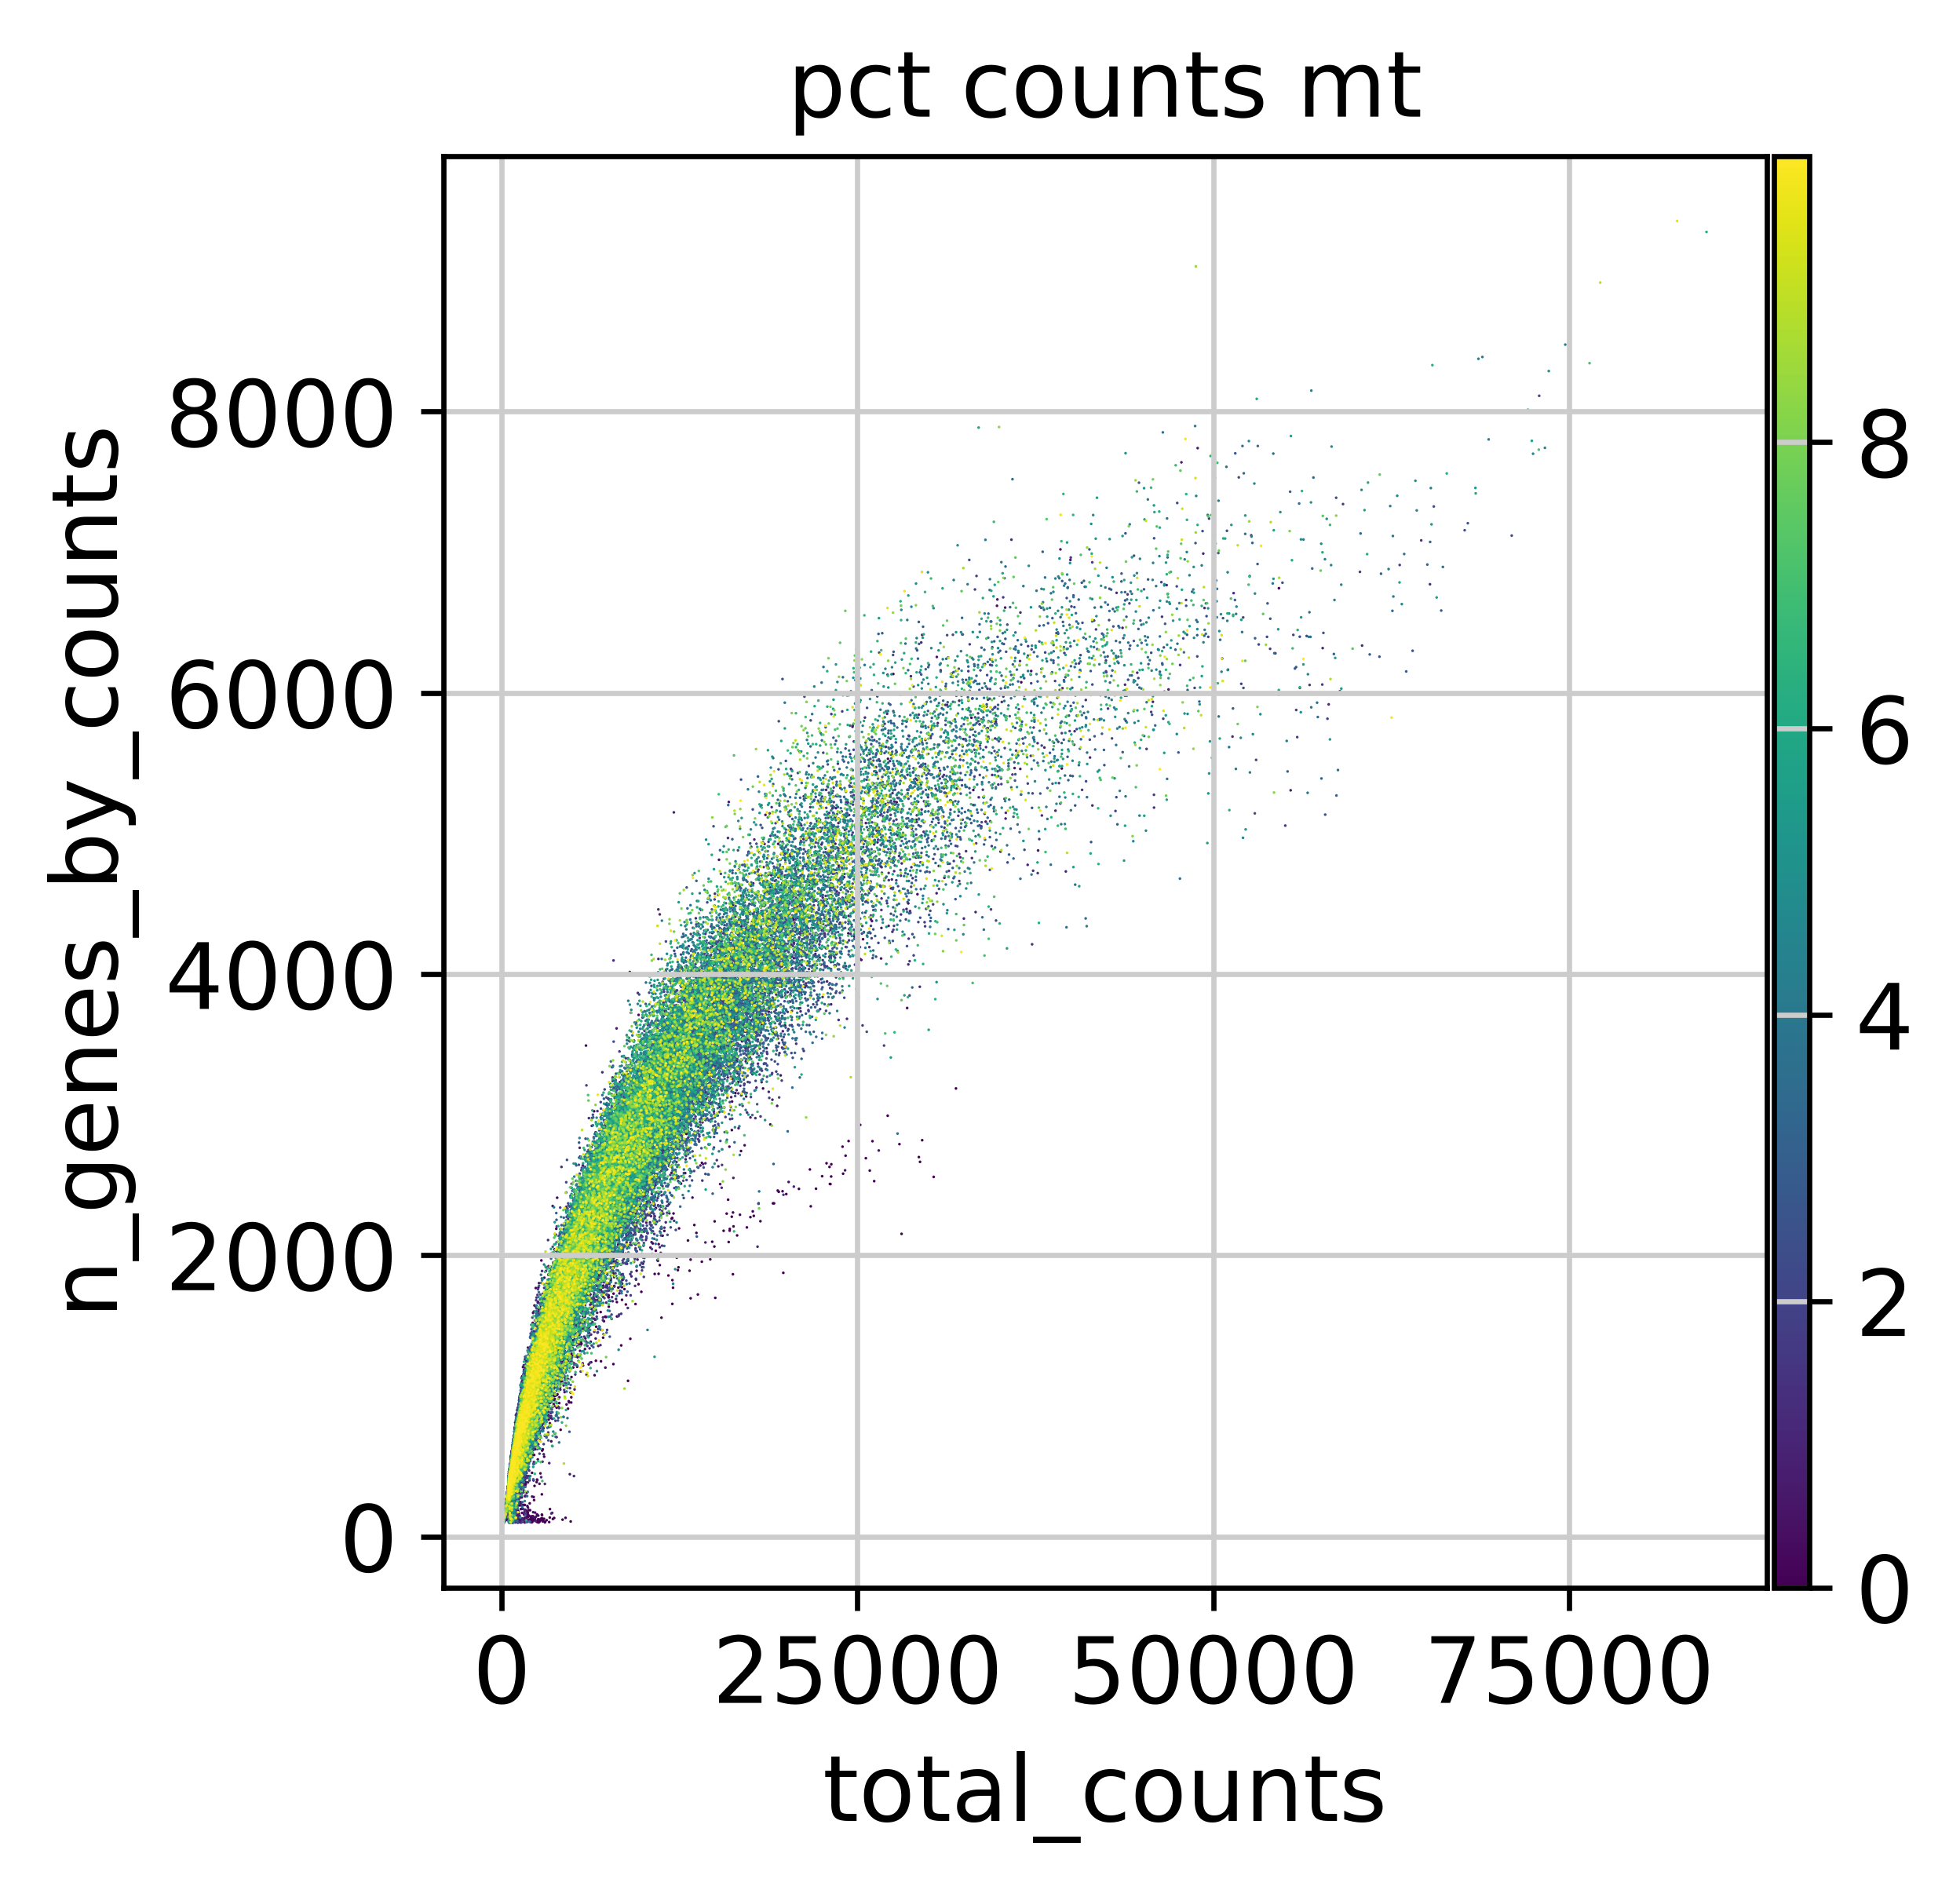

In [59]:
# The usual complexity scatter: counts vs genes, colored by mitochondrial content.
sc.pl.scatter(
    nonimm,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    save="_nonimm_counts_vs_genes_unintegrated.png",
)

## Cell filter

Same criteria as 01_2 (`pct_counts_mt < 10`, `n_genes_by_counts > 100`), re-applied rather than
assumed: the report below is the evidence that the subset carries no cell that the full-object filter
would have rejected, and the place to tighten `MIN_GENES` / `MAX_PCT_MT` if the figures above call
for it.

In [60]:
n_before = nonimm.n_obs
keep = (
    (nonimm.obs["pct_counts_mt"] < MAX_PCT_MT) &
    (nonimm.obs["n_genes_by_counts"] > MIN_GENES)
)
print("Cells removed by each criterion (marginal, not mutually exclusive):")
print(f"  pct_mt >= {MAX_PCT_MT}   : {int((nonimm.obs['pct_counts_mt'] >= MAX_PCT_MT).sum()):,}")
print(f"  n_genes <= {MIN_GENES}  : {int((nonimm.obs['n_genes_by_counts'] <= MIN_GENES).sum()):,}")

nonimm = nonimm[keep].copy()
print(f"\nCells: {n_before:,} -> {nonimm.n_obs:,} ({100 * nonimm.n_obs / n_before:.1f}% retained)")

Cells removed by each criterion (marginal, not mutually exclusive):
  pct_mt >= 10   : 0
  n_genes <= 100  : 0

Cells: 176,610 -> 176,610 (100.0% retained)


## Gene filter

Placed after the cell filter, as in 01_2. Two reasons rather than one here: zero-count genes break
scran's `computeSumFactors`, and the 30,869 genes of the full object include everything that was only
expressed in the 443,083 immune cells that just left.

In [61]:
n_genes_before = nonimm.n_vars
detected = np.asarray((nonimm.X > 0).sum(axis=0)).ravel()
print(f"Total number of genes: {n_genes_before:,}")
print(f"  detected in 0 cells        : {int((detected == 0).sum()):,}")
print(f"  detected in < {MIN_CELLS} cells  : {int((detected < MIN_CELLS).sum()):,}")

sc.pp.filter_genes(nonimm, min_cells=MIN_CELLS)
print(f"Genes after the filter: {nonimm.n_vars:,} "
      f"({100 * nonimm.n_vars / n_genes_before:.1f}% retained)")

Total number of genes: 30,869
  detected in 0 cells        : 901
  detected in < 3 cells  : 3,016
filtered out 3016 genes that are detected in less than 3 cells
Genes after the filter: 27,853 (90.2% retained)


### QC figures (after the cell and gene filters)


In [ ]:
violin_qc(nonimm.obs, "after_cell_and_gene_filter")

## Batch census

`cohort` is the batch key of everything downstream: scib's `hvg_batch` selects genes per patient
before merging, and DRVI is trained with `dispersion='gene-batch'`, which fits a dispersion per gene
*and* per batch. Both degrade on a patient contributing a few hundred cells, so the census is part of
the record even when nothing is dropped.

Two criteria are reported here, and only the second is on by default:

- **size** (`DROP_SMALL_COHORTS`, off): cohorts under `MIN_CELLS_PER_COHORT` cells
- **completeness** (`DROP_INCOMPLETE_COHORTS`, on): cohorts with 0 non-immune cells in any of
  BASE / PD1 / RTPD1. The design of this dataset is longitudinal - the same patient sampled at the
  three timepoints - and a cohort covering only part of them cannot contribute to the treatment
  contrast that phase 03 is about, while it still costs a full batch in the integration and a
  dispersion column in DRVI. Note that the emptiness is judged *after* the QC filters above: a
  cohort can lose a timepoint here that it had in the full object.

In [63]:
cells_per_cohort = nonimm.obs[BATCH_KEY].value_counts()
print(f"{cells_per_cohort.size} cohorts | "
      f"min {cells_per_cohort.min():,} ({cells_per_cohort.idxmin()}) | "
      f"median {int(cells_per_cohort.median()):,} | "
      f"max {cells_per_cohort.max():,} ({cells_per_cohort.idxmax()})")

small = cells_per_cohort[cells_per_cohort < MIN_CELLS_PER_COHORT]
if len(small):
    print(f"\n{len(small)} cohort(s) below {MIN_CELLS_PER_COHORT} cells:")
    print(small)
else:
    print(f"\nNo cohort below {MIN_CELLS_PER_COHORT} cells.")

cells_per_cohort.sort_values()

34 cohorts | min 314 (Patient30) | median 2,812 | max 21,693 (Patient53)

No cohort below 200 cells.


cohort
Patient30      314
Patient66      467
Patient20      479
Patient04      579
Patient03      609
Patient07      678
Patient02      701
Patient64      843
Patient23      857
Patient09      917
Patient15     1077
Patient05     1367
Patient11     1401
Patient01     1809
Patient06     2171
Patient18     2519
Patient10     2612
Patient12     3013
Patient57     3074
Patient48     3978
Patient39     5062
Patient46     5095
Patient19     5554
Patient45     6058
Patient17     6385
Patient26     6907
Patient42     9037
Patient47    10270
Patient63    11555
Patient56    13145
Patient16    14409
Patient43    15920
Patient52    16055
Patient53    21693
Name: count, dtype: int64

In [64]:
cohort_x_treatment = pd.crosstab(
    nonimm.obs[BATCH_KEY], nonimm.obs[TREATMENT_KEY]
).reindex(columns=list(REQUIRED_TREATMENTS), fill_value=0)

incomplete = cohort_x_treatment.index[(cohort_x_treatment == 0).any(axis=1)]
if len(incomplete):
    print(f"{len(incomplete)} cohort(s) missing at least one of "
          f"{'/'.join(REQUIRED_TREATMENTS)}:")
    for c in incomplete:
        missing = [t for t in REQUIRED_TREATMENTS if cohort_x_treatment.loc[c, t] == 0]
        print(f"  {c}: no {'/'.join(missing)} ({int(cells_per_cohort[c]):,} cells)")
else:
    print(f"Every cohort covers all of {'/'.join(REQUIRED_TREATMENTS)}.")

cohort_x_treatment

2 cohort(s) missing at least one of BASE/PD1/RTPD1:
  Patient01: no PD1 (1,809 cells)
  Patient30: no RTPD1 (314 cells)


treatment,BASE,PD1,RTPD1
cohort,,,
Patient01,1398,0,411
Patient02,143,248,310
Patient03,207,269,133
Patient04,433,32,114
Patient05,223,821,323
Patient06,1378,138,655
Patient07,258,111,309
Patient09,406,266,245
Patient10,1235,946,431


In [65]:
to_drop = pd.Index([])
if DROP_SMALL_COHORTS:
    to_drop = to_drop.union(small.index)
if DROP_INCOMPLETE_COHORTS:
    to_drop = to_drop.union(incomplete)

if len(to_drop):
    reasons = {c: [] for c in to_drop}
    for c in to_drop:
        if DROP_SMALL_COHORTS and c in small.index:
            reasons[c].append(f"< {MIN_CELLS_PER_COHORT} cells")
        if DROP_INCOMPLETE_COHORTS and c in incomplete:
            missing = [t for t in REQUIRED_TREATMENTS if cohort_x_treatment.loc[c, t] == 0]
            reasons[c].append("no " + "/".join(missing))
    print(f"Dropping {len(to_drop)} cohort(s):")
    for c in to_drop:
        print(f"  {c}: {'; '.join(reasons[c])} ({int(cells_per_cohort[c]):,} cells)")

    n_before, n_cohorts_before = nonimm.n_obs, nonimm.obs[BATCH_KEY].nunique()
    nonimm = nonimm[~nonimm.obs[BATCH_KEY].isin(to_drop)].copy()

    # Every categorical can lose a level with a whole patient (sample, response, and the
    # cell types only that patient carried), not just the batch key.
    for col in nonimm.obs.columns:
        if isinstance(nonimm.obs[col].dtype, pd.CategoricalDtype):
            nonimm.obs[col] = nonimm.obs[col].cat.remove_unused_categories()

    print(f"\nCells   : {n_before:,} -> {nonimm.n_obs:,} "
          f"({100 * nonimm.n_obs / n_before:.1f}% retained)")
    print(f"Cohorts : {n_cohorts_before} -> {nonimm.obs[BATCH_KEY].nunique()}")

    # Genes can fall below the threshold once a whole patient is gone; zero-count ones would
    # break scran, so this refilter is not optional.
    n_genes_before = nonimm.n_vars
    sc.pp.filter_genes(nonimm, min_cells=MIN_CELLS)
    print(f"Genes   : {n_genes_before:,} -> {nonimm.n_vars:,}")

    # QC columns are per-cell sums over the genes that are actually left.
    sc.pp.calculate_qc_metrics(
        nonimm, qc_vars=["mt", "ribo"], inplace=True, percent_top=None, log1p=True,
    )
    print("\nCohort x treatment after the drop:")
    print(pd.crosstab(nonimm.obs[BATCH_KEY], nonimm.obs[TREATMENT_KEY]))
else:
    print("No cohort dropped (both criteria are off, or nothing meets them).")

Dropping 2 cohort(s):
  Patient01: no PD1 (1,809 cells)
  Patient30: no RTPD1 (314 cells)

Cells   : 176,610 -> 174,487 (98.8% retained)
Cohorts : 34 -> 32
filtered out 27 genes that are detected in less than 3 cells
Genes   : 27,853 -> 27,826

Cohort x treatment after the drop:
treatment  BASE    PD1  RTPD1
cohort                       
Patient02   143    248    310
Patient03   207    269    133
Patient04   433     32    114
Patient05   223    821    323
Patient06  1378    138    655
Patient07   258    111    309
Patient09   406    266    245
Patient10  1235    946    431
Patient11   779    522    100
Patient12   246    898   1869
Patient15   130    594    353
Patient16  2427  11261    721
Patient17   501    449   5435
Patient18   657   1700    162
Patient19   562   1184   3808
Patient20    91    192    196
Patient23   278    409    170
Patient26  4349   2219    339
Patient39   602   4040    420
Patient42  2596    592   5849
Patient43   312  12699   2909
Patient45  2341   3597    120


### QC figures (after the cohort drops)

The last round: the cells of the dropped cohorts are gone, the gene filter has run a second time
and the QC columns have been recomputed over the genes that are actually left. These are the
distributions of the object that gets written.

In [ ]:
if len(to_drop):
    violin_qc(nonimm.obs, "after_cohort_drop")
else:
    print("no cohort dropped: the round above is already the final one")

In [66]:
# Post-conditions, checked before writing rather than discovered by scran an hour later.
counts_values = nonimm.layers["counts"].data
x_values = nonimm.X.data
assert np.allclose(x_values, np.round(x_values)), ".X must hold raw integer counts"
assert np.array_equal(x_values, counts_values), ".X and layers['counts'] must be identical here"
assert int(np.asarray(nonimm.X.sum(axis=0) == 0).sum()) == 0, "zero-count genes left; scran would fail"
assert "size_factors" not in nonimm.obs, "the phase-01 size factors are still here"
assert not nonimm.obsm and not nonimm.varm and not nonimm.obsp, "a derived slot survived"
assert nonimm.obs[FRACTION_KEY].nunique() == 1, "the subset is not a single fraction"

if DROP_INCOMPLETE_COHORTS:
    final_table = pd.crosstab(
        nonimm.obs[BATCH_KEY], nonimm.obs[TREATMENT_KEY]
    ).reindex(columns=list(REQUIRED_TREATMENTS), fill_value=0)
    assert not (final_table == 0).any().any(), \
        f"cohorts still missing a timepoint: {final_table.index[(final_table == 0).any(axis=1)].tolist()}"

print("All post-conditions passed.")

All post-conditions passed.


## Saving dataset

`shiao.h5ad` was written by a pandas-3 stack, so its `obs`/`var` indices (the cell barcodes and
the gene symbols) come back as pandas `StringArray`s. anndata refuses to write those by default,
because no reader older than 0.11 understands them - which is a real constraint here: DRVI and
scGen live in environments pinned to older anndata. `02_integration_benchmark/utils/h5ad_compat.py`
already solves this: it downcasts the indices and the extension-dtype columns to plain object
arrays and then re-opens the file to check what actually landed on disk.

Doing it once, here at the head of the chain, is enough - every later step writes an object read
back from this file, and none of them adds a string column.

In [67]:
import sys
sys.path.insert(0, os.path.join(REPO_ROOT, "02_integration_benchmark", "utils"))
from h5ad_compat import write_h5ad_compat

write_h5ad_compat(nonimm, OUTPUT_H5AD, compression="gzip")
print(f"Wrote {OUTPUT_H5AD} "
      f"({nonimm.n_obs:,} cells x {nonimm.n_vars:,} genes, "
      f"{os.path.getsize(OUTPUT_H5AD) / 1024 ** 3:.2f} GB on disk)")
nonimm

[h5ad_compat] 4 dtype adjustments before writing:
    obs.index -> object
    obs['predicted_doublet'] boolean -> numpy
    var.index -> object
    var['gene_ids'] string -> object
[h5ad_compat] wrote /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/shiao_nonimm_raw.h5ad, readable by anndata >=0.7


['obs.index -> object',
 "obs['predicted_doublet'] boolean -> numpy",
 'var.index -> object',
 "var['gene_ids'] string -> object"]

Wrote /home/albertoc/Desktop/QCB-Master-Thesis/datasets/03_nonimm/shiao_nonimm_raw.h5ad (174,487 cells x 27,826 genes, 1.27 GB on disk)


AnnData object with n_obs × n_vars = 174487 × 27826
    obs: 'sample', 'batch', 'cohort', 'treatment', 'fraction', 'dataset_origin', 'response', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'is_doublet_shiao', 'high_umi_doublet', 'cell_type', 'celltypist_predicted'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts', None (.X)

## Next

```bash
export DATA_DIR=~/Desktop/QCB-Master-Thesis/datasets
cd 03_drvi_non_immune/03_1_subsetting
./subsetting_all.sh
```

which produces `shiao_nonimm.h5ad` (definitive) and `shiao_nonimm_hvg_2k.h5ad` (DRVI input for
03_2). Then inspect the result with [visualization_nonimm.ipynb](visualization_nonimm.ipynb).